# Walk-Forward ML Strategy — BTC / ETH / XRP / BNB Long Signals

## Strategy Overview

Rolling walk-forward XGBoost trained on 8 crypto assets using macro, derivatives, and on-chain features. Outputs a calibrated probability that next-day return exceeds +30 bps.

**Signal logic**
- **LONG** signal fires when calibrated `prob > 0.80` (τ = 0.80, fixed)
- Filter: long-only on BTC / ETH / XRP / BNB — the four coins with confirmed edge at this threshold
- Short signals excluded: 46% hit rate across all coins, below breakeven after fees
- No position when `0.20 ≤ prob ≤ 0.80` (flat zone)

**Walk-forward window**
- Train: 3 years → Val: 3 months (calibration + threshold check) → Test: 1 month (OOS) → Step: 1 month
- Each fold is fully independent — no data leakage between train and test windows

**Feature set (~35 features)**
Price momentum (1/3/7/14/30d), realised volatility, RSI, z-scores, skew/kurtosis, funding rates, open interest, long/short ratio, Deribit DVOL, macro (DXY, SPX, gold — lagged 1 day to avoid lookahead), DeFi TVL, stablecoin mcap, BTC correlation/beta, calendar dummies.

**Use cases**
1. **Discretionary trigger** — go long the signalled coin when a high-confidence LONG fires
2. **Regime indicator** — monitor average model probability across the 4 coins as a broader bull/bear read

**Backtest summary (2022–2026, long-only, 4 coins)**
31 signals · 74.2% hit rate · Active Sharpe 8.50 · MDD −3.1% · Calmar 4.51

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

REPO = Path('../../..').resolve()
sys.path.insert(0, str(REPO / 'infrastructure' / 'ml' / 'features'))
sys.path.insert(0, str(REPO / 'infrastructure' / 'ml'))
sys.path.insert(0, str(REPO / 'infrastructure' / 'backtester'))

from build_dataset import UNIVERSE
from walk_forward import run_walk_forward, DEFAULT_CONFIG
import ml_metrics as metrics

FEATURES_DIR = REPO / 'topics' / 'ml-prediction' / 'data' / 'features'
COST_BPS = 6
print('Repo root:', REPO)

Repo root: C:\Users\user\Documents\Epsilon Fund\Epsilon-Quant-Research


In [2]:
from build_dataset import save_all
print('Rebuilding features...')
save_all()

Rebuilding features...
  BTCUSDT... 2156 rows, 1857 labelled (86% survive deadband)
  ETHUSDT... 2156 rows, 1949 labelled (90% survive deadband)
  SOLUSDT... 2089 rows, 1966 labelled (94% survive deadband)
  BNBUSDT... 2500 rows, 2234 labelled (89% survive deadband)
  XRPUSDT... 2156 rows, 1953 labelled (91% survive deadband)
  DOGEUSDT... 2489 rows, 2273 labelled (91% survive deadband)
  LINKUSDT... 2156 rows, 2041 labelled (95% survive deadband)
  AVAXUSDT... 2047 rows, 1951 labelled (95% survive deadband)


## 2. Load Feature Matrix

Loads pre-built feature parquets from `data/features/`. Each row is one coin × one day (~17,700 rows across 8 coins).

Re-run the **rebuild-features** cell above only when raw data has been updated (new OHLCV, macro, or futures data). Feature building is slow — skip it on routine notebook runs.

In [3]:
dfs = []
for sym in UNIVERSE:
    p = FEATURES_DIR / f'{sym}_features.parquet'
    if p.exists():
        dfs.append(pd.read_parquet(p))

all_df = pd.concat(dfs).sort_index()
print(f'Loaded {len(all_df):,} rows across {len(UNIVERSE)} symbols')
print(f'Date range: {all_df.index[0].date()} to {all_df.index[-1].date()}')
print(f'Labelled rows: {all_df["label"].notna().sum():,}')

Loaded 17,749 rows across 8 symbols
Date range: 2019-06-24 to 2026-04-30
Labelled rows: 16,224


## 3. Run Walk-Forward

Trains one fold per month. Each fold:
1. **Scale** — RobustScaler fitted on train set only, applied to val and test
2. **Train** — XGBoost (300 trees, max_depth=4, lr=0.03, subsample=0.8)
3. **Calibrate** — IsotonicRegression fitted on val-set raw probabilities → corrects overconfidence
4. **Threshold** — τ = 0.80 fixed; LONG if `prob > τ`, SHORT if `prob < 1−τ`, FLAT otherwise
5. **Score** — calibrated probabilities applied to the held-out test month

Takes ~3–5 minutes. Output: `preds` (all OOS signal rows) and `folds_meta` (one dict per fold, containing the trained model, scaler, and calibrator — used for SHAP analysis below).

In [4]:
config = {
    **DEFAULT_CONFIG,
    'cost_bps': COST_BPS,
}

print('Running walk-forward...')
preds, folds_meta = run_walk_forward(all_df, config)

Running walk-forward...
  Fold 00  train 2019-06-24–2022-06-30  test 2022-09-29–2022-10-28  τ=0.80  signals=0
  Fold 01  train 2019-07-25–2022-07-30  test 2022-10-29–2022-11-27  τ=0.80  signals=3
  Fold 02  train 2019-08-25–2022-08-29  test 2022-11-28–2022-12-27  τ=0.80  signals=0
  Fold 03  train 2019-09-27–2022-09-28  test 2022-12-28–2023-01-26  τ=0.80  signals=0
  Fold 04  train 2019-10-27–2022-10-28  test 2023-01-27–2023-02-25  τ=0.80  signals=8
  Fold 05  train 2019-11-27–2022-11-27  test 2023-02-26–2023-03-27  τ=0.80  signals=3
  Fold 06  train 2019-12-28–2022-12-27  test 2023-03-28–2023-04-26  τ=0.80  signals=0
  Fold 07  train 2020-01-27–2023-01-26  test 2023-04-27–2023-05-26  τ=0.80  signals=0
  Fold 08  train 2020-02-27–2023-02-25  test 2023-05-27–2023-06-25  τ=0.80  signals=5
  Fold 09  train 2020-03-28–2023-03-27  test 2023-06-26–2023-07-25  τ=0.80  signals=8
  Fold 10  train 2020-04-27–2023-04-26  test 2023-07-26–2023-08-24  τ=0.80  signals=0
  Fold 11  train 2020-05-27–20

In [5]:
# ── Regime filter: long-only, top-4 coins ────────────────────────────────────
# Short signals have 46% hit rate (below breakeven).
# SOL, AVAX, LINK, DOGE all below 50% hit rate at tau=0.80.
FILTER_COINS = ['BTCUSDT', 'ETHUSDT', 'XRPUSDT', 'BNBUSDT']

preds_f = preds[
    (preds['pred'] == 1.0) &
    (preds['symbol'].isin(FILTER_COINS))
].copy()

print(f'All signals:      {preds["pred"].notna().sum():.0f}')
print(f'Filtered signals: {len(preds_f)}  (long-only, {", ".join(FILTER_COINS)})')

All signals:      131
Filtered signals: 31  (long-only, BTCUSDT, ETHUSDT, XRPUSDT, BNBUSDT)


## 4. Filtered Strategy: Long-Only, BTC / ETH / XRP / BNB

The actionable output. Restricts to long signals on the four coins with confirmed edge at τ = 0.80.

**Why this filter?**
- Short signals: 46% hit rate across all coins — below breakeven after fees
- SOL / AVAX / LINK / DOGE: consistently below 50% hit rate at τ = 0.80
- BTC / ETH / XRP / BNB: 66–80% hit rate, consistent across years

Metrics below (Sharpe, hit rate, equity curve, per-coin breakdown, full signal list) reflect this filtered universe only. This is the version to monitor for live signals.

  FILTERED SCORECARD  (long-only, 4 coins)
  Sharpe (active days)       8.50
  Sharpe (full calendar)     1.29
  Calmar ratio               4.51
  Max drawdown              -3.1%
  Annualised return         14.1%
  Total return              34.7%
  Hit rate                  74.2%
  Signals                      31

  YEAR     SHARPE   RETURN   SIGNALS
  ----------------------------------
  2023       1.66    17.7%        14
  2024       1.41    13.0%        15
  2025       1.00     0.0%         2


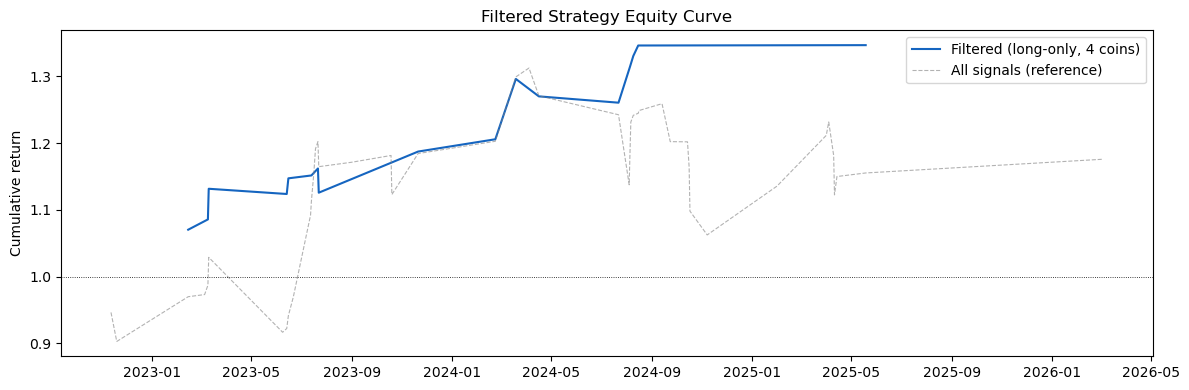


== Per-Coin (filtered) ==
         signals  hit_rate  avg_confidence
symbol                                    
XRPUSDT        5     0.800           0.933
BTCUSDT        9     0.778           0.935
ETHUSDT        8     0.750           0.927
BNBUSDT        9     0.667           0.922

== All Filtered Signals ==
             symbol  confidence  label outcome
2025-05-19  BTCUSDT    1.000000    1.0     WIN
2025-05-19  XRPUSDT    1.000000    0.0    LOSE
2024-08-15  BTCUSDT    0.833333    1.0     WIN
2024-08-15  XRPUSDT    0.833333    1.0     WIN
2024-08-15  ETHUSDT    0.833333    1.0     WIN
2024-08-09  XRPUSDT    0.833333    1.0     WIN
2024-08-09  BNBUSDT    0.833333    1.0     WIN
2024-08-09  ETHUSDT    0.833333    1.0     WIN
2024-08-05  BNBUSDT    0.833333    1.0     WIN
2024-07-22  ETHUSDT    0.833333    1.0     WIN
2024-07-22  BTCUSDT    0.833333    0.0    LOSE
2024-07-22  BNBUSDT    0.833333    0.0    LOSE
2024-04-16  BNBUSDT    1.000000    0.0    LOSE
2024-04-16  ETHUSDT    1.0000

In [6]:
eq_f  = metrics.equity_curve(preds_f, COST_BPS)
mdd_f = metrics.max_drawdown(eq_f)

active_rets_f   = eq_f.pct_change().dropna()
sharpe_active_f = float(active_rets_f.mean() / active_rets_f.std() * np.sqrt(252))

full_idx_f    = pd.date_range(eq_f.index[0], eq_f.index[-1], freq='D')
daily_full_f  = eq_f.pct_change().reindex(full_idx_f).fillna(0)
sharpe_full_f = float(daily_full_f.mean() / daily_full_f.std() * np.sqrt(365))

years_f   = (eq_f.index[-1] - eq_f.index[0]).days / 365.25
ann_ret_f = eq_f.iloc[-1] ** (1 / years_f) - 1
calmar_f  = ann_ret_f / abs(mdd_f)

print('=' * 50)
print('  FILTERED SCORECARD  (long-only, 4 coins)')
print('=' * 50)
print(f'  Sharpe (active days)   {sharpe_active_f:>8.2f}')
print(f'  Sharpe (full calendar) {sharpe_full_f:>8.2f}')
print(f'  Calmar ratio           {calmar_f:>8.2f}')
print(f'  Max drawdown           {mdd_f:>8.1%}')
print(f'  Annualised return      {ann_ret_f:>8.1%}')
print(f'  Total return           {eq_f.iloc[-1]-1:>8.1%}')
print(f'  Hit rate               {metrics.hit_rate(preds_f):>8.1%}')
print(f'  Signals                {len(preds_f):>8}')
print('=' * 50)

print()
by_year_f = metrics.sharpe_by_year(preds_f, COST_BPS)
print(f'  {"YEAR":<6} {"SHARPE":>8} {"RETURN":>8} {"SIGNALS":>9}')
print('  ' + '-' * 34)
for yr, row in by_year_f.iterrows():
    print(f'  {yr:<6} {row["sharpe"]:>8.2f} {row["ret_pct"]:>7.1f}% {int(row["n_signals"]):>9}')

# Equity curve
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(eq_f.index, eq_f.values, color='#1565c0', linewidth=1.5, label='Filtered (long-only, 4 coins)')
if len(eq_f):
    eq_all = metrics.equity_curve(preds, COST_BPS)
    ax.plot(eq_all.index, eq_all.values, color='grey', linewidth=0.8,
            linestyle='--', alpha=0.6, label='All signals (reference)')
ax.axhline(1, color='black', linewidth=0.6, linestyle=':')
ax.set_title('Filtered Strategy Equity Curve')
ax.set_ylabel('Cumulative return')
ax.legend()
plt.tight_layout()
plt.show()

# Per-coin breakdown
preds_f_copy = preds_f.copy()
preds_f_copy['correct'] = preds_f_copy['pred'] == preds_f_copy['label']
coin_f = (preds_f_copy.groupby('symbol')
    .agg(signals=('pred', 'count'),
         hit_rate=('correct', 'mean'),
         avg_confidence=('confidence', 'mean'))
    .round(3)
    .sort_values('hit_rate', ascending=False))
print('\n== Per-Coin (filtered) ==')
print(coin_f.to_string())

# Signal list
print('\n== All Filtered Signals ==')
sig_list = preds_f_copy[['symbol', 'confidence', 'label', 'correct']].copy()
sig_list['outcome'] = sig_list['correct'].map({True: 'WIN', False: 'LOSE'})
sig_list.index = sig_list.index.date
sig_list = sig_list.drop(columns=['correct'])
print(sig_list.sort_index(ascending=False).to_string())

## 5. Model Diagnostics

Validation of model quality — run these when re-evaluating or after changing the feature set. Not needed for day-to-day signal use.

### Hit Rate by Confidence Bucket

Checks whether higher model confidence actually predicts better. At τ = 0.80 all active signals land in the ≥80% bucket by construction — this table mainly verifies the signal count is consistent.

In [7]:
hr_table = metrics.hit_rate_by_bucket(preds)
print(hr_table.to_string(index=False))

confidence_bucket  n_signals  hit_rate  avg_confidence
         80%–101%        131      0.55           0.953


### Calibration Check

Predicted probability (x-axis) vs actual frequency of label = 1 (y-axis). Points near the diagonal = well-calibrated model. The IsotonicRegression calibrator is fitted on the val set each fold specifically to fix this.

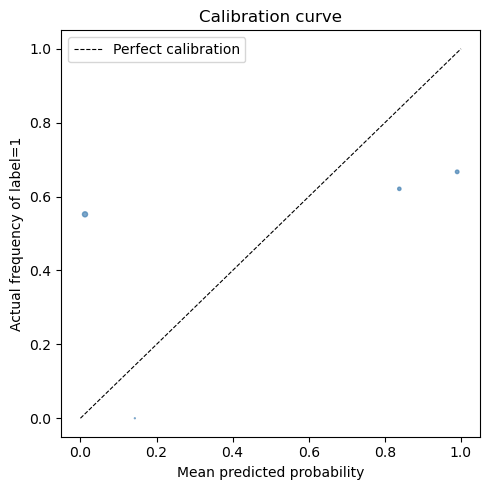

In [8]:
cal = metrics.calibration_table(preds)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(cal['mean_pred_prob'], cal['actual_freq'], s=cal['n']/5,
           color='steelblue', alpha=0.7)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Perfect calibration')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Actual frequency of label=1')
ax.set_title('Calibration curve')
ax.legend()
plt.tight_layout()
plt.show()

### Feature Importance

Average XGBoost gain-based importance across all folds. Macro features (SPX, DXY, gold returns) and on-chain flows (TVL, stablecoin mcap) consistently dominate — the model is primarily a macro/regime detector rather than a pure price-action model.

In [9]:
imp = metrics.feature_importance(folds_meta, top_n=35)
print(imp.to_string(index=False))

          feature  importance
       spx_ret_1d    0.041121
       tvl_chg_7d    0.040966
       dxy_ret_1d    0.040358
      gold_ret_1d    0.040252
       spx_ret_7d    0.040124
       dxy_ret_7d    0.039725
      gold_ret_7d    0.039277
stablecoin_chg_7d    0.038909
           ret_1d    0.038179
      day_of_week    0.036248
        oi_chg_1d    0.033022
     btc_beta_30d    0.030245
      zscore_ma60    0.028932
        ls_chg_7d    0.028199
           rsi_14    0.027763
           ret_3d    0.027331
   funding_avg_7d    0.026741
           ret_7d    0.026607
         ls_ratio    0.026478
         skew_30d    0.026405
          rvol_7d    0.026332
          ret_14d    0.026093
      zscore_ma20    0.025877
         rvol_30d    0.025807
       funding_1d    0.025647
        oi_chg_7d    0.025625
          ret_30d    0.025593
   funding_zscore    0.024563
         rvol_14d    0.023368
         kurt_30d    0.022235
     btc_corr_30d    0.022107
      dvol_chg_7d    0.015079
          

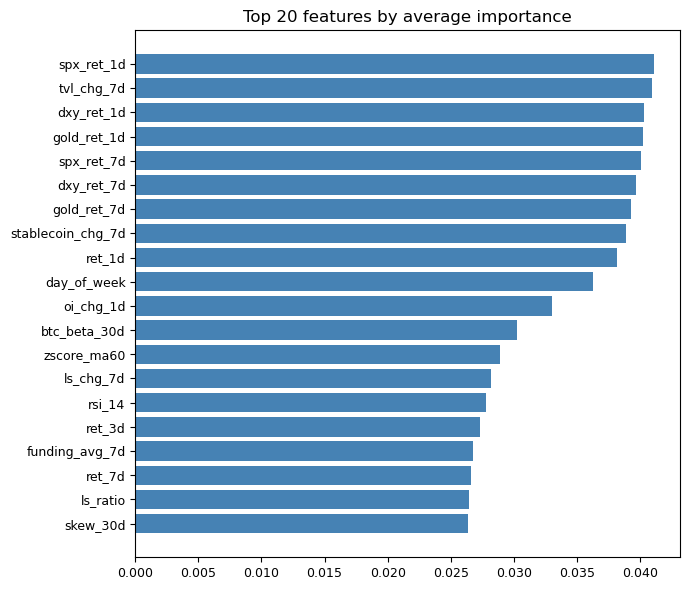

In [10]:
imp = metrics.feature_importance(folds_meta, top_n=20)

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(imp['feature'][::-1], imp['importance'][::-1], color='steelblue')
ax.set_title('Top 20 features by average importance')
ax.tick_params(labelsize=9)
plt.tight_layout()
plt.show()

## 6. Signal Report

Full breakdown of all high-conviction signals across all 8 coins (pre-filter). Shows the long vs short split, per-coin stats, cluster months (>8 signals/month = treat with caution — model uncertainty is higher when many signals fire together), and the 20 most recent signals.

In [11]:
active = preds[preds['pred'].notna()].copy()
active['direction'] = active['pred'].map({1.0: 'LONG', 0.0: 'SHORT'})
active['correct']   = active['pred'] == active['label']
active['pnl_pct']   = (active['next_ret'] * active['pred'].map({1.0: 1, 0.0: -1}) * 100).round(2)

# ── Long vs short breakdown ───────────────────────────────────────────────────
print('== Long vs Short ==')
dir_stats = (active.groupby('direction')
    .agg(signals=('pred', 'count'),
         hit_rate=('correct', 'mean'),
         avg_pnl_pct=('pnl_pct', 'mean'),
         avg_confidence=('confidence', 'mean'))
    .round(3))
print(dir_stats.to_string())

# ── Per-coin breakdown ────────────────────────────────────────────────────────
print('\n== Per-Coin Breakdown ==')
coin_stats = (active.groupby('symbol')
    .agg(signals=('pred', 'count'),
         hit_rate=('correct', 'mean'),
         longs=('direction', lambda x: (x == 'LONG').sum()),
         shorts=('direction', lambda x: (x == 'SHORT').sum()),
         avg_confidence=('confidence', 'mean'))
    .round(3)
    .sort_values('signals', ascending=False))
print(coin_stats.to_string())

# ── Cluster warning ───────────────────────────────────────────────────────────
print('\n== Monthly Signal Count (cluster check — >8 = treat with caution) ==')
monthly = active.groupby(active.index.to_period('M')).size().rename('signals')
flagged = monthly[monthly > 8]
if flagged.empty:
    print('  No cluster months.')
else:
    for period, count in flagged.items():
        print(f'  *** {period}  {count} signals — HIGH ACTIVITY, treat with caution ***')

# ── Most recent signals ───────────────────────────────────────────────────────
print('\n== Most Recent 20 Signals ==')
recent = (active[['symbol', 'direction', 'confidence', 'pnl_pct', 'correct']]
          .sort_index(ascending=False)
          .head(20)
          .copy())
recent.index = recent.index.date
print(recent.to_string())

== Long vs Short ==
           signals  hit_rate  avg_pnl_pct  avg_confidence
direction                                                
LONG            62     0.645        1.201           0.919
SHORT           69     0.464       -0.942           0.984

== Per-Coin Breakdown ==
          signals  hit_rate  longs  shorts  avg_confidence
symbol                                                    
SOLUSDT        19     0.474      9      10           0.944
AVAXUSDT       17     0.471      9       8           0.935
ETHUSDT        17     0.647      8       9           0.962
LINKUSDT       17     0.471      7      10           0.963
BTCUSDT        16     0.562      9       7           0.950
DOGEUSDT       16     0.438      6      10           0.954
XRPUSDT        15     0.800      5      10           0.972
BNBUSDT        14     0.571      9       5           0.950

== Monthly Signal Count (cluster check — >8 = treat with caution) ==
  *** 2024-08  18 signals — HIGH ACTIVITY, treat with caution 

## 7. SHAP: Per-Signal Feature Drivers

Explains *which features drove each individual signal* in the most recent fold with active signals. Uses SHAP TreeExplainer on the stored XGBoost model — no re-training required.

For each signal: top 6 features by |SHAP value| with direction (↑ = pushed toward LONG, ↓ = pushed toward SHORT). The bar chart shows mean |SHAP| across all active signals in the fold.

SHAP for fold 41  (test 2026-02-10 → 2026-03-11)
6 active signals

  2026-03-04    ETHUSDT     SHORT  conf=1.000
    ↓  spx_ret_7d              shap=-0.1533
    ↓  spx_ret_1d              shap=-0.1426
    ↓  tvl_chg_7d              shap=-0.1201
    ↓  dxy_ret_7d              shap=-0.1195
    ↓  ret_1d                  shap=-0.0957
    ↓  dxy_ret_1d              shap=-0.0878

  2026-03-04    SOLUSDT     SHORT  conf=1.000
    ↓  spx_ret_7d              shap=-0.1611
    ↓  spx_ret_1d              shap=-0.1411
    ↓  dxy_ret_7d              shap=-0.1242
    ↓  tvl_chg_7d              shap=-0.1156
    ↓  ret_1d                  shap=-0.0916
    ↓  dxy_ret_1d              shap=-0.0904

  2026-03-04    AVAXUSDT    SHORT  conf=0.903
    ↓  spx_ret_7d              shap=-0.1568
    ↓  spx_ret_1d              shap=-0.1470
    ↓  tvl_chg_7d              shap=-0.1257
    ↓  dxy_ret_7d              shap=-0.1178
    ↓  ret_1d                  shap=-0.0943
    ↓  dxy_ret_1d              shap=-0.0844



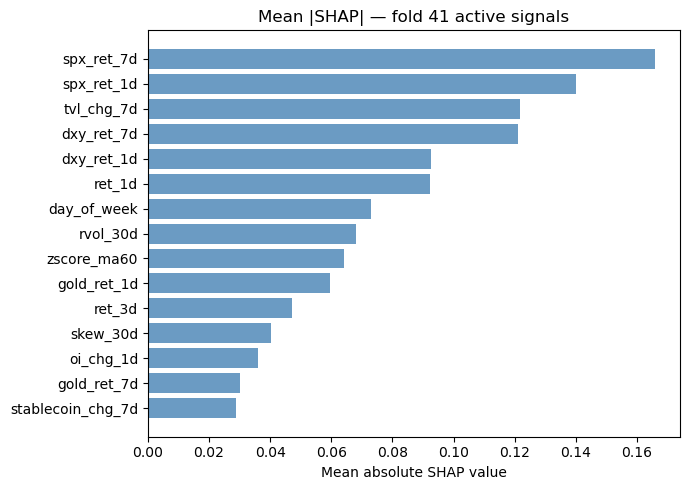

In [12]:
import shap

last_fold = next(
    f for f in reversed(folds_meta)
    if preds[(preds['fold'] == f['fold']) & preds['pred'].notna()].shape[0] > 0
)

model_f     = last_fold['model']
scaler_f    = last_fold['scaler']
feat_cols_f = last_fold['feat_cols']

fold_active = preds[(preds['fold'] == last_fold['fold']) & preds['pred'].notna()].copy()
fold_active['direction'] = fold_active['pred'].map({1.0: 'LONG', 0.0: 'SHORT'})

test_feats   = all_df.loc[all_df.index.isin(fold_active.index) &
                           all_df['symbol'].isin(fold_active['symbol'])][feat_cols_f]
test_feats_s = scaler_f.transform(test_feats.fillna(test_feats.median()))

explainer   = shap.TreeExplainer(model_f)
shap_values = explainer.shap_values(test_feats_s)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

print(f'SHAP for fold {last_fold["fold"]}  '
      f'(test {last_fold["test_start"]} → {last_fold["test_end"]})')
print(f'{len(fold_active)} active signals\n')

top_n = 6
for i, (idx, row) in enumerate(fold_active.iterrows()):
    sv_row  = sv[i]
    top_idx = np.argsort(np.abs(sv_row))[::-1][:top_n]
    drivers = [(feat_cols_f[j], sv_row[j]) for j in top_idx]
    print(f'  {str(idx.date()):12s}  {row["symbol"]:10s}  {row["direction"]:5s}  conf={row["confidence"]:.3f}')
    for feat, val in drivers:
        print(f'    {"↑" if val > 0 else "↓"}  {feat:<22s}  shap={val:+.4f}')
    print()

mean_abs_shap = np.abs(sv).mean(axis=0)
imp_df = pd.DataFrame({'feature': feat_cols_f, 'mean_abs_shap': mean_abs_shap})
imp_df = imp_df.sort_values('mean_abs_shap', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(imp_df['feature'][::-1], imp_df['mean_abs_shap'][::-1], color='steelblue', alpha=0.8)
ax.set_title(f'Mean |SHAP| — fold {last_fold["fold"]} active signals')
ax.set_xlabel('Mean absolute SHAP value')
plt.tight_layout()
plt.show()

## 8. Universe Diagnostics

Per-coin hit rates across all signals at τ = 0.80. This table drives the `FILTER_COINS` selection — revisit after re-running the walk-forward. If a coin drops below 50% hit rate over multiple folds, remove it from the filter.

== Universe Assessment ==
          signals  hit_rate  longs  shorts  avg_confidence      recommendation
symbol                                                                        
XRPUSDT        15     0.800      5      10           0.972      KEEP  (strong)
ETHUSDT        17     0.647      8       9           0.962      KEEP  (strong)
BNBUSDT        14     0.571      9       5           0.950    KEEP  (marginal)
BTCUSDT        16     0.562      9       7           0.950    KEEP  (marginal)
SOLUSDT        19     0.474      9      10           0.944  REVIEW (below 50%)
AVAXUSDT       17     0.471      9       8           0.935  REVIEW (below 50%)
LINKUSDT       17     0.471      7      10           0.963  REVIEW (below 50%)
DOGEUSDT       16     0.438      6      10           0.954  REVIEW (below 50%)


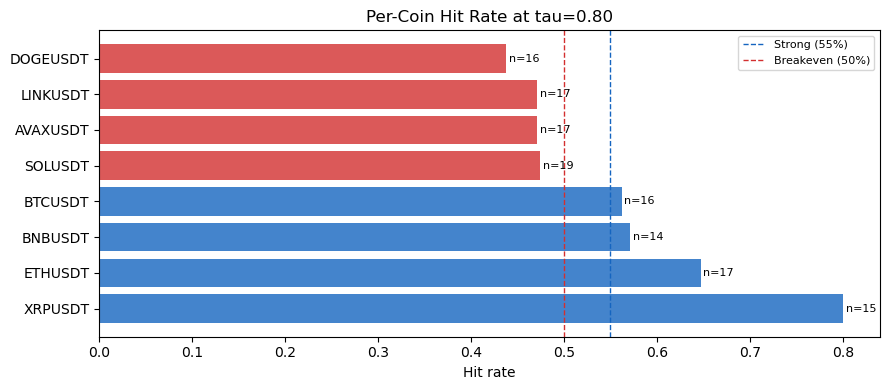

In [13]:
active = preds[preds['pred'].notna()].copy()
active['correct'] = active['pred'] == active['label']
active['direction'] = active['pred'].map({1.0: 'LONG', 0.0: 'SHORT'})

coin_stats = (active.groupby('symbol')
    .agg(signals=('pred', 'count'),
         hit_rate=('correct', 'mean'),
         longs=('direction', lambda x: (x == 'LONG').sum()),
         shorts=('direction', lambda x: (x == 'SHORT').sum()),
         avg_confidence=('confidence', 'mean'))
    .round(3)
    .sort_values('hit_rate', ascending=False))

def _recommend(row):
    if row['signals'] < 5:
        return 'TOO FEW SIGNALS'
    if row['hit_rate'] >= 0.58:
        return 'KEEP  (strong)'
    if row['hit_rate'] >= 0.50:
        return 'KEEP  (marginal)'
    return 'REVIEW (below 50%)'

coin_stats['recommendation'] = coin_stats.apply(_recommend, axis=1)

print('== Universe Assessment ==')
print(coin_stats.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#1565c0' if h >= 0.55 else ('#f57c00' if h >= 0.50 else '#d32f2f')
          for h in coin_stats['hit_rate']]
bars = ax.barh(coin_stats.index, coin_stats['hit_rate'], color=colors, alpha=0.8)
ax.axvline(0.55, color='#1565c0', linestyle='--', linewidth=1, label='Strong (55%)')
ax.axvline(0.50, color='#d32f2f', linestyle='--', linewidth=1, label='Breakeven (50%)')
for bar, (_, row) in zip(bars, coin_stats.iterrows()):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f'n={int(row["signals"])}', va='center', fontsize=8)
ax.set_xlabel('Hit rate')
ax.set_title('Per-Coin Hit Rate at tau=0.80')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 9. Cross-Coin Consensus

Daily net score: each LONG counts +1, each SHORT counts −1, summed across all 8 coins. A high positive score (≥4) means multiple coins are bullish simultaneously — a stronger regime signal than any single coin. Use this as a broader market read alongside the filtered long signals.

== Consensus Signal Days ==
  Total signal days: 45
  Strong bull days (score >= 4): 6
  Bull days        (score >= 2): 12
  Mixed days       (score  0-1): 22
  Bear days        (score <= -2): 11
  Strong bear days (score <= -4): 7

== Strong Consensus Days (|score| >= 3) ==
            consensus_score  longs  shorts       regime
2023-02-14                8      8       0  STRONG BULL
2023-07-14                3      3       0         BULL
2023-10-20               -7      0       7  STRONG BEAR
2024-03-19                3      3       0         BULL
2024-04-16                6      6       0  STRONG BULL
2024-07-22                4      4       0  STRONG BULL
2024-08-05                3      3       0         BULL
2024-08-09                5      5       0  STRONG BULL
2024-08-15                6      6       0  STRONG BULL
2024-09-23               -3      0       3         BEAR
2024-10-14               -6      0       6  STRONG BEAR
2024-11-07               -7      0       7  STRONG B

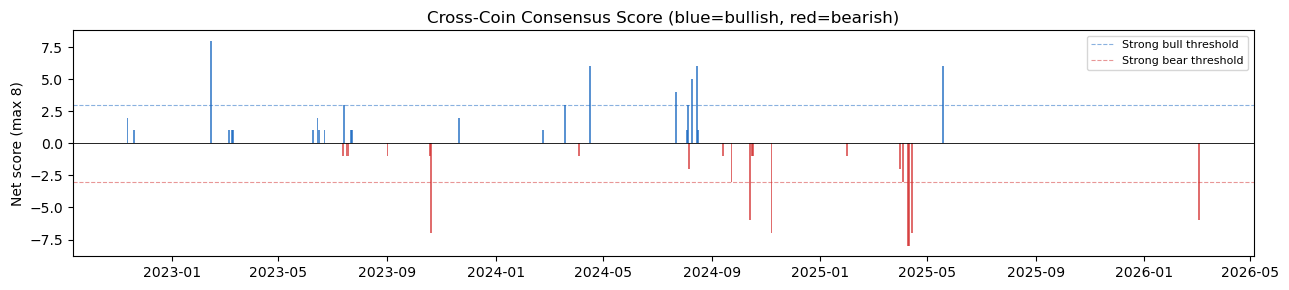

In [14]:
active = preds[preds['pred'].notna()].copy()
active['direction'] = active['pred'].map({1.0: 'LONG', 0.0: 'SHORT'})
active['score']     = active['pred'].map({1.0: 1, 0.0: -1})

# Daily net score: sum of +1 (long) and -1 (short) across all coins each day
daily_consensus = active.groupby(level=0)['score'].sum().rename('consensus_score')
daily_longs     = active[active['score'] ==  1].groupby(level=0).size().rename('longs')
daily_shorts    = active[active['score'] == -1].groupby(level=0).size().rename('shorts')

consensus = pd.concat([daily_consensus, daily_longs, daily_shorts], axis=1).fillna(0).astype(int)
consensus['regime'] = consensus['consensus_score'].apply(
    lambda s: 'STRONG BULL' if s >= 4 else ('BULL' if s >= 2 else
              ('STRONG BEAR' if s <= -4 else ('BEAR' if s <= -2 else 'MIXED')))
)

print('== Consensus Signal Days ==')
print(f'  Total signal days: {len(consensus)}')
print(f'  Strong bull days (score >= 4): {(consensus["consensus_score"] >= 4).sum()}')
print(f'  Bull days        (score >= 2): {(consensus["consensus_score"] >= 2).sum()}')
print(f'  Mixed days       (score  0-1): {(consensus["consensus_score"].abs() <= 1).sum()}')
print(f'  Bear days        (score <= -2): {(consensus["consensus_score"] <= -2).sum()}')
print(f'  Strong bear days (score <= -4): {(consensus["consensus_score"] <= -4).sum()}')

print('\n== Strong Consensus Days (|score| >= 3) ==')
strong = consensus[consensus['consensus_score'].abs() >= 3].copy()
if strong.empty:
    print('  None in sample.')
else:
    strong.index = strong.index.date
    print(strong.to_string())

# Plot consensus score over time
fig, ax = plt.subplots(figsize=(13, 3))
colors = ['#d32f2f' if s < 0 else '#1565c0' for s in daily_consensus.values]
ax.bar(daily_consensus.index, daily_consensus.values, color=colors, alpha=0.7, width=2)
ax.axhline(0, color='black', linewidth=0.6)
ax.axhline(3,  color='#1565c0', linewidth=0.8, linestyle='--', alpha=0.5, label='Strong bull threshold')
ax.axhline(-3, color='#d32f2f', linewidth=0.8, linestyle='--', alpha=0.5, label='Strong bear threshold')
ax.set_title('Cross-Coin Consensus Score (blue=bullish, red=bearish)')
ax.set_ylabel('Net score (max 8)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()